# Task 4 - Anomaly Detection

### Objective
Detect abnormal equipment behavior in connected-building telemetry.

**Target behaviors**
- Sudden power spikes
- Excessive vibration
- Sensor drift / behavior change
- Abnormal temperature patterns
- Equipment degradation

### Approach
A hybrid framework is used because no single anomaly detector captures every type of abnormal behavior.

**Methods:** Statistical Thresholding → Isolation Forest → Autoencoder → DBSCAN Clustering → Change-Point Detection → Combined Anomaly Score

## 01. Load + Validate Data

First, load the telemetry and metadata and perform basic quality checks.

### Why?
Anomaly detection should not mistake data-quality problems such as duplicate rows or invalid values for equipment anomalies.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import DBSCAN

SEED = 42
np.random.seed(SEED)

# Find raw data
possible_dirs = [Path("../data/raw"), Path("data/raw")]

DATA_DIR = next(
    (p for p in possible_dirs if (p / "sensor_telemetry.csv").exists()),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find data/raw/sensor_telemetry.csv. "
        "Run the data-generation script first."
    )

telemetry = pd.read_csv(DATA_DIR / "sensor_telemetry.csv")
metadata = pd.read_csv(DATA_DIR / "asset_metadata.csv")

telemetry["timestamp"] = pd.to_datetime(telemetry["timestamp"])
metadata["installation_date"] = pd.to_datetime(metadata["installation_date"])

telemetry = telemetry.sort_values(
    ["asset_id", "timestamp"]
).reset_index(drop=True)

print("Telemetry shape :", telemetry.shape)
print("Metadata shape  :", metadata.shape)
print("Date range      :", telemetry["timestamp"].min(), "to", telemetry["timestamp"].max())
print("Unique assets   :", telemetry["asset_id"].nunique())
print("Unique buildings:", telemetry["building_id"].nunique())

display(telemetry.head())

Telemetry shape : (259200, 12)
Metadata shape  : (30, 9)
Date range      : 2026-01-01 00:00:00 to 2026-03-31 23:45:00
Unique assets   : 30
Unique buildings: 6


,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag
0,2026-01-01 00:00:00,SITE_01,BLDG_01,ASSET_001,18.621,54.498,1.521,0.222,8.971,31,Idle,0
1,2026-01-01 00:15:00,SITE_01,BLDG_01,ASSET_001,19.923,47.778,1.505,0.191,8.939,43,Idle,0
2,2026-01-01 00:30:00,SITE_01,BLDG_01,ASSET_001,19.225,53.328,1.386,0.150,7.824,35,Idle,0
3,2026-01-01 00:45:00,SITE_01,BLDG_01,ASSET_001,19.856,56.998,1.528,0.206,54.215,40,Cooling,0
4,2026-01-01 01:00:00,SITE_01,BLDG_01,ASSET_001,19.841,54.713,1.549,0.181,43.278,25,Cooling,0


In [2]:
# Dashboard / artifact output location
# When this notebook is run from the Jupyter Notebook folder,
# ../outputs points to the project-level outputs folder.
OUTPUTS_DIR = (
    Path("../outputs")
    if Path("../outputs").exists()
    else Path("outputs")
)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Basic validation

duplicate_count = telemetry.duplicated(
    subset=["asset_id", "timestamp"]
).sum()

negative_vibration = (
    telemetry["vibration"].dropna() < 0
).sum()

invalid_fault_flag = (
    ~telemetry["fault_flag"].isin([0, 1])
).sum()

missing_pct = (
    telemetry[
        ["temperature", "humidity", "pressure",
         "vibration", "power_consumption"]
    ]
    .isna()
    .mean()
    .mul(100)
    .round(3)
)

print("Duplicate asset/timestamp rows :", duplicate_count)
print("Negative vibration values      :", negative_vibration)
print("Invalid fault flags            :", invalid_fault_flag)

print("\nSensor missingness (%):")
display(missing_pct)

Duplicate asset/timestamp rows : 0
Negative vibration values      : 0
Invalid fault flags            : 0

Sensor missingness (%):


temperature          0.984
humidity             1.028
pressure             0.772
vibration            0.788
power_consumption    0.000
dtype: float64

## 02. Merge Metadata + Asset Baselines

Merge asset metadata so anomaly detection can be interpreted by equipment type.

We also create asset-level baselines for the main sensor signals.

### Why?
A value that is normal for one asset can be unusual for another. Asset-specific baselines are therefore more useful than one global threshold.

In [4]:
df = telemetry.merge(
    metadata[
        [
            "asset_id",
            "asset_type",
            "manufacturer",
            "installation_date",
            "capacity",
            "parent_asset_id"
        ]
    ],
    on="asset_id",
    how="left"
)

df["asset_age_years"] = (
    (df["timestamp"] - df["installation_date"]).dt.days
    / 365.25
)

sensor_columns = [
    "temperature",
    "pressure",
    "vibration",
    "power_consumption"
]

# Asset-level historical mean and standard deviation
for col in sensor_columns:
    df[f"{col}_asset_mean"] = (
        df.groupby("asset_id")[col]
        .transform("mean")
    )

    df[f"{col}_asset_std"] = (
        df.groupby("asset_id")[col]
        .transform("std")
    )

display(
    df[
        [
            "timestamp",
            "asset_id",
            "asset_type",
            "temperature",
            "temperature_asset_mean",
            "vibration",
            "vibration_asset_mean"
        ]
    ].head()
)

,timestamp,asset_id,asset_type,temperature,temperature_asset_mean,vibration,vibration_asset_mean
0,2026-01-01 00:00:00,ASSET_001,Chiller,18.621,22.627763,0.222,0.183774
1,2026-01-01 00:15:00,ASSET_001,Chiller,19.923,22.627763,0.191,0.183774
2,2026-01-01 00:30:00,ASSET_001,Chiller,19.225,22.627763,0.150,0.183774
3,2026-01-01 00:45:00,ASSET_001,Chiller,19.856,22.627763,0.206,0.183774
4,2026-01-01 01:00:00,ASSET_001,Chiller,19.841,22.627763,0.181,0.183774


## 03. Feature Engineering

Create short-term and long-term behavior features.

### Features
- 1-hour rolling mean
- 6-hour rolling mean
- 24-hour rolling mean
- 1-hour change
- 6-hour change

### Why?
A sudden spike and a gradual degradation are different patterns. Rolling and trend features help the models capture both.

In [5]:
df = df.sort_values(
    ["asset_id", "timestamp"]
).reset_index(drop=True)

grouped = df.groupby("asset_id")

for col in sensor_columns:

    shifted = grouped[col].shift(1)

    df[f"{col}_mean_1h"] = (
        shifted.groupby(df["asset_id"])
        .transform(
            lambda x: x.rolling(4, min_periods=2).mean()
        )
    )

    df[f"{col}_mean_6h"] = (
        shifted.groupby(df["asset_id"])
        .transform(
            lambda x: x.rolling(24, min_periods=4).mean()
        )
    )

    df[f"{col}_mean_24h"] = (
        shifted.groupby(df["asset_id"])
        .transform(
            lambda x: x.rolling(96, min_periods=12).mean()
        )
    )

    df[f"{col}_change_1h"] = (
        df.groupby("asset_id")[col].diff(4)
    )

    df[f"{col}_change_6h"] = (
        df.groupby("asset_id")[col].diff(24)
    )

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

display(
    df[
        [
            "timestamp",
            "asset_id",
            "vibration",
            "vibration_mean_1h",
            "vibration_mean_6h",
            "vibration_change_1h",
            "power_consumption",
            "power_consumption_change_1h"
        ]
    ].head(10)
)

,timestamp,asset_id,vibration,vibration_mean_1h,vibration_mean_6h,vibration_change_1h,power_consumption,power_consumption_change_1h
0,2026-01-01 00:00:00,ASSET_001,0.222,NaN,NaN,NaN,8.971,NaN
1,2026-01-01 00:15:00,ASSET_001,0.191,NaN,NaN,NaN,8.939,NaN
2,2026-01-01 00:30:00,ASSET_001,0.150,0.206500,NaN,NaN,7.824,NaN
3,2026-01-01 00:45:00,ASSET_001,0.206,0.187667,NaN,NaN,54.215,NaN
4,2026-01-01 01:00:00,ASSET_001,0.181,0.192250,0.192250,-0.041,43.278,34.307
5,2026-01-01 01:15:00,ASSET_001,0.238,0.182000,0.190000,0.047,9.909,0.970
6,2026-01-01 01:30:00,ASSET_001,0.174,0.193750,0.198000,0.024,9.948,2.124
7,2026-01-01 01:45:00,ASSET_001,0.215,0.199750,0.194571,0.009,8.935,-45.280
8,2026-01-01 02:00:00,ASSET_001,NaN,0.202000,0.197125,NaN,11.097,-32.181
9,2026-01-01 02:15:00,ASSET_001,0.176,0.209000,0.197125,-0.062,3.652,-6.257


## 04. Statistical Thresholding

### Method
Use an asset-specific **IQR rule**:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

### Why?
This is simple and interpretable. It is useful for directly identifying extreme power, vibration, temperature or pressure readings before applying more complex models.

In [6]:
stat_sensors = [
    "temperature",
    "pressure",
    "vibration",
    "power_consumption"
]

for col in stat_sensors:

    q1 = df.groupby("asset_id")[col].transform(
        lambda x: x.quantile(0.25)
    )
    q3 = df.groupby("asset_id")[col].transform(
        lambda x: x.quantile(0.75)
    )

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[f"{col}_stat_anomaly"] = (
        (df[col] < lower) | (df[col] > upper)
    ).astype(int)

stat_columns = [
    f"{col}_stat_anomaly"
    for col in stat_sensors
]

df["statistical_anomaly"] = (
    df[stat_columns].max(axis=1)
)

print(
    "Total statistical anomalies:",
    int(df["statistical_anomaly"].sum())
)

display(
    df[stat_columns].sum()
    .sort_values(ascending=False)
)

Total statistical anomalies: 6007


vibration_stat_anomaly            4038
pressure_stat_anomaly             1861
power_consumption_stat_anomaly     211
temperature_stat_anomaly             0
dtype: int64

## 05. Isolation Forest

### Method
Isolation Forest identifies observations that are easy to isolate from normal observations.

### Why?
Statistical thresholds usually inspect sensors individually. Isolation Forest can detect **multivariate abnormal behavior**, such as high vibration + unusual pressure + high power occurring together.

In [7]:
if_features = [
    "temperature",
    "humidity",
    "pressure",
    "vibration",
    "power_consumption",
    "occupancy_count",
    "temperature_change_1h",
    "pressure_change_1h",
    "vibration_change_1h",
    "power_consumption_change_1h",
    "vibration_mean_6h",
    "power_consumption_mean_6h"
]

if_imputer = SimpleImputer(strategy="median")
X_if = if_imputer.fit_transform(df[if_features])

if_scaler = StandardScaler()
X_if = if_scaler.fit_transform(X_if)

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=SEED,
    n_jobs=-1
)

isolation_forest.fit(X_if)

df["isolation_forest_score"] = (
    -isolation_forest.score_samples(X_if)
)

df["isolation_forest_anomaly"] = (
    isolation_forest.predict(X_if) == -1
).astype(int)

print(
    "Isolation Forest anomalies:",
    int(df["isolation_forest_anomaly"].sum())
)

display(
    df[
        [
            "timestamp",
            "asset_id",
            "isolation_forest_score",
            "isolation_forest_anomaly"
        ]
    ]
    .sort_values("isolation_forest_score", ascending=False)
    .head(10)
)

Isolation Forest anomalies: 2592


,timestamp,asset_id,isolation_forest_score,isolation_forest_anomaly
136448,2026-03-13 08:00:00,ASSET_016,0.687869,1
136449,2026-03-13 08:15:00,ASSET_016,0.682209,1
6878,2026-03-13 15:30:00,ASSET_001,0.676672,1
6880,2026-03-13 16:00:00,ASSET_001,0.671571,1
133694,2026-02-12 15:30:00,ASSET_016,0.669498,1
6877,2026-03-13 15:15:00,ASSET_001,0.663561,1
6879,2026-03-13 15:45:00,ASSET_001,0.660939,1
41825,2026-03-17 16:15:00,ASSET_005,0.660179,1
3138,2026-02-02 16:30:00,ASSET_001,0.659130,1
135200,2026-02-28 08:00:00,ASSET_016,0.654899,1


## 06. Autoencoder

### Method
Train an autoencoder on mostly normal observations and use reconstruction error as the anomaly score.

### Why?
The autoencoder learns the normal relationship between multiple sensors. An observation that cannot be reconstructed well is potentially abnormal.

A high reconstruction error therefore indicates unusual multivariate behavior.

In [8]:
ae_features = [
    "temperature",
    "humidity",
    "pressure",
    "vibration",
    "power_consumption"
]

ae_imputer = SimpleImputer(strategy="median")
X_ae = ae_imputer.fit_transform(df[ae_features])

ae_scaler = StandardScaler()
X_ae = ae_scaler.fit_transform(X_ae)

# Use observations without obvious statistical anomalies
normal_mask = df["statistical_anomaly"].eq(0)

X_ae_train = X_ae[normal_mask.values]

autoencoder = MLPRegressor(
    hidden_layer_sizes=(16, 8, 16),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED
)

autoencoder.fit(
    X_ae_train,
    X_ae_train
)

reconstructed = autoencoder.predict(X_ae)

df["autoencoder_error"] = np.mean(
    (X_ae - reconstructed) ** 2,
    axis=1
)

ae_threshold = df.loc[
    normal_mask,
    "autoencoder_error"
].quantile(0.99)

df["autoencoder_anomaly"] = (
    df["autoencoder_error"] > ae_threshold
).astype(int)

print("Autoencoder threshold:", round(ae_threshold, 4))
print(
    "Autoencoder anomalies:",
    int(df["autoencoder_anomaly"].sum())
)

Autoencoder threshold: 0.0
Autoencoder anomalies: 4091


## 07. Clustering — DBSCAN

### Method
DBSCAN groups dense observations and labels isolated points as noise.

### Why?
Some abnormal operating conditions may form small or isolated behavior groups rather than simple extreme values. DBSCAN provides another way to identify such unusual observations.

We use a representative sample to keep computation practical on the full telemetry dataset.

In [9]:
cluster_features = [
    "temperature",
    "pressure",
    "vibration",
    "power_consumption"
]

cluster_imputer = SimpleImputer(strategy="median")
X_cluster = cluster_imputer.fit_transform(
    df[cluster_features]
)

cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(X_cluster)

sample_size = min(30000, len(df))
rng = np.random.default_rng(SEED)

sample_idx = rng.choice(
    len(df),
    size=sample_size,
    replace=False
)

dbscan = DBSCAN(
    eps=0.8,
    min_samples=15,
    n_jobs=-1
)

labels = dbscan.fit_predict(
    X_cluster[sample_idx]
)

df["cluster_anomaly"] = 0

df.loc[
    df.index[sample_idx],
    "cluster_anomaly"
] = (labels == -1).astype(int)

cluster_count = len(
    set(labels) - {-1}
)

print("Sampled observations:", sample_size)
print("Clusters detected:", cluster_count)
print(
    "Cluster outliers:",
    int(df["cluster_anomaly"].sum())
)

Sampled observations: 30000
Clusters detected: 2
Cluster outliers: 150


## 08. Change Point Detection

### Method
Compare short-term behavior with a longer historical baseline.

A large standardized difference between the recent 1-hour mean and the 24-hour baseline is treated as a potential behavior change.

### Why?
Sensor drift and equipment degradation may not produce one extreme reading. Instead, the operating level gradually changes and remains different from the previous baseline.

In [10]:
change_features = [
    "temperature",
    "pressure",
    "vibration",
    "power_consumption"
]

for col in change_features:

    short_mean = (
        df.groupby("asset_id")[col]
        .transform(
            lambda x: x.shift(1).rolling(
                4, min_periods=2
            ).mean()
        )
    )

    long_mean = (
        df.groupby("asset_id")[col]
        .transform(
            lambda x: x.shift(1).rolling(
                96, min_periods=24
            ).mean()
        )
    )

    long_std = (
        df.groupby("asset_id")[col]
        .transform(
            lambda x: x.shift(1).rolling(
                96, min_periods=24
            ).std()
        )
    )

    df[f"{col}_change_score"] = (
        (short_mean - long_mean).abs()
        / (long_std + 1e-6)
    )

change_score_columns = [
    f"{col}_change_score"
    for col in change_features
]

# A strong change in at least one signal
df["change_point_signal"] = (
    df[change_score_columns]
    .gt(3)
    .any(axis=1)
    .astype(int)
)

print(
    "Potential change points:",
    int(df["change_point_signal"].sum())
)

Potential change points: 395


## 09. Combine Anomaly Scores

Each method captures a different kind of abnormality.

We combine them using an interpretable evidence score:

- Statistical threshold → 1
- Isolation Forest → 1
- Autoencoder → 1
- DBSCAN → 1
- Change point → 1

### Why?
A single detector can produce false positives. Multiple independent signals provide stronger evidence that an observation deserves investigation.

In [11]:
signal_columns = [
    "statistical_anomaly",
    "isolation_forest_anomaly",
    "autoencoder_anomaly",
    "cluster_anomaly",
    "change_point_signal"
]

df["anomaly_score"] = df[signal_columns].sum(axis=1)

def severity_label(score):
    if score >= 4:
        return "Critical"
    if score >= 3:
        return "Anomaly"
    if score >= 2:
        return "Watch"
    return "Normal"

df["severity"] = df["anomaly_score"].apply(
    severity_label
)

print("Severity distribution:")
display(
    df["severity"]
    .value_counts()
    .rename_axis("Severity")
    .to_frame("Count")
)

Severity distribution:


,Count
Severity,
Normal,257154
Watch,1214
Anomaly,715
Critical,117


## 10. Visualizations

The visualizations focus on the signals that are most useful operationally:

1. Power spikes
2. Excessive vibration
3. Temperature / behavior changes
4. Overall anomaly score

The anomaly points are shown directly on the time series so the result is easy to explain.

### 10.1 Power Spike Visualization

**Purpose:** identify sudden energy/power deviations and show whether the hybrid detector flags them.

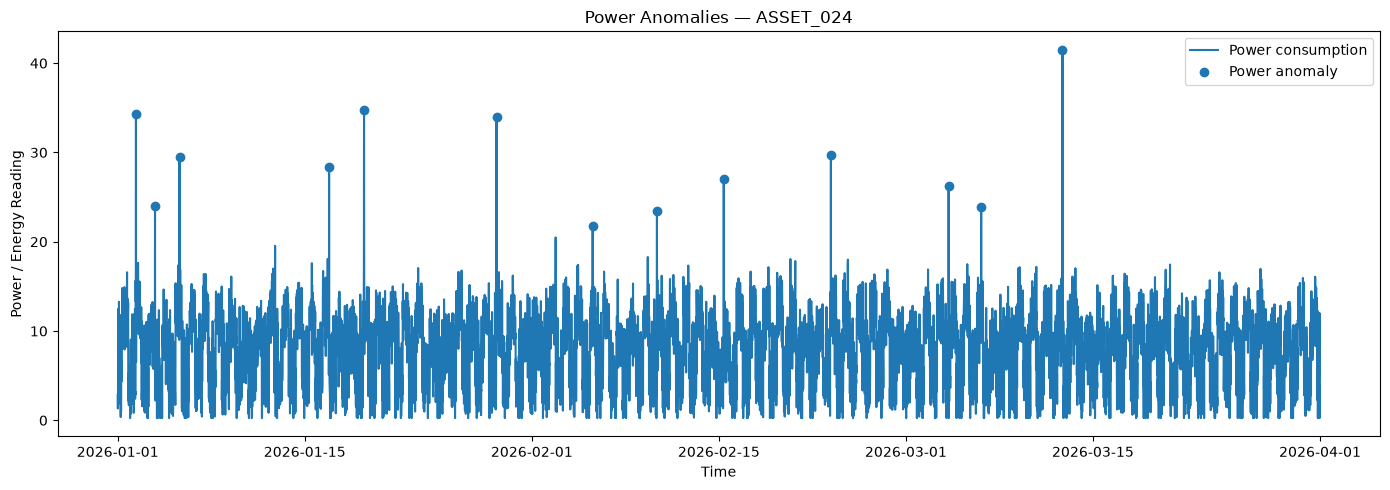

In [12]:
# Select an asset with the largest power anomaly count
power_asset = (
    df.groupby("asset_id")["power_consumption_stat_anomaly"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

power_plot = df[
    df["asset_id"] == power_asset
].sort_values("timestamp")

flagged = power_plot[
    power_plot["power_consumption_stat_anomaly"] == 1
]

plt.figure(figsize=(14, 5))

plt.plot(
    power_plot["timestamp"],
    power_plot["power_consumption"],
    label="Power consumption"
)

plt.scatter(
    flagged["timestamp"],
    flagged["power_consumption"],
    label="Power anomaly"
)

plt.title(f"Power Anomalies — {power_asset}")
plt.xlabel("Time")
plt.ylabel("Power / Energy Reading")
plt.legend()
plt.tight_layout()
plt.show()

### 10.2 Vibration Anomaly Visualization

**Purpose:** show abnormal mechanical behavior, especially for pumps and chillers.

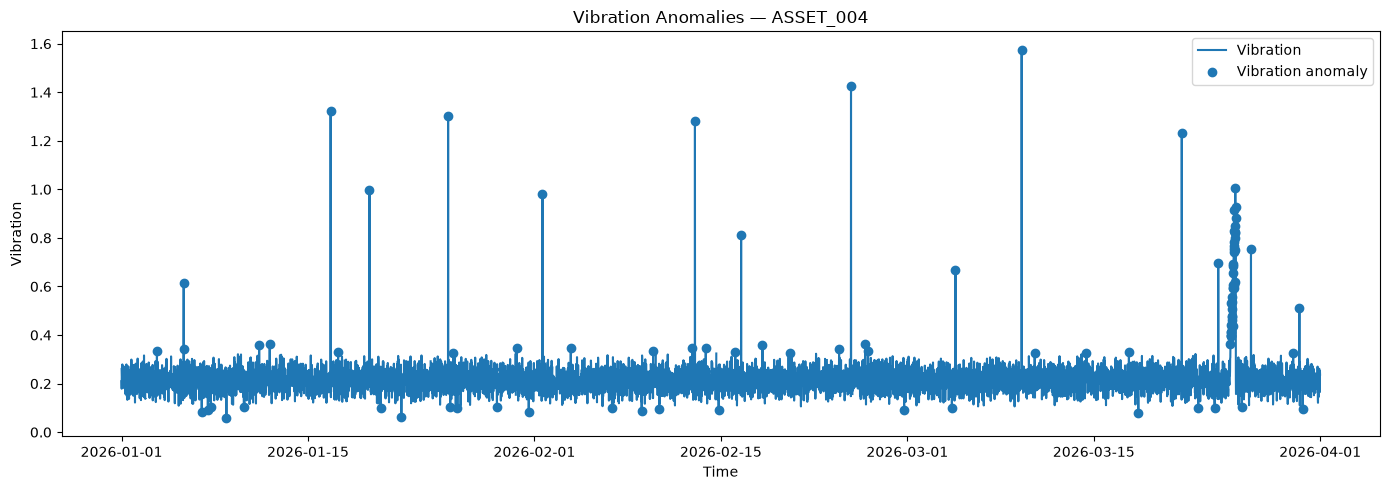

In [13]:
pump_assets = metadata.loc[
    metadata["asset_type"].eq("Pump"),
    "asset_id"
].tolist()

vibration_asset = pump_assets[0] if pump_assets else power_asset

vibration_plot = df[
    df["asset_id"] == vibration_asset
].sort_values("timestamp")

flagged = vibration_plot[
    vibration_plot["vibration_stat_anomaly"] == 1
]

plt.figure(figsize=(14, 5))

plt.plot(
    vibration_plot["timestamp"],
    vibration_plot["vibration"],
    label="Vibration"
)

plt.scatter(
    flagged["timestamp"],
    flagged["vibration"],
    label="Vibration anomaly"
)

plt.title(f"Vibration Anomalies — {vibration_asset}")
plt.xlabel("Time")
plt.ylabel("Vibration")
plt.legend()
plt.tight_layout()
plt.show()

### 10.3 Temperature / Behavior Change

**Purpose:** detect persistent changes that may indicate abnormal operating conditions or sensor drift.

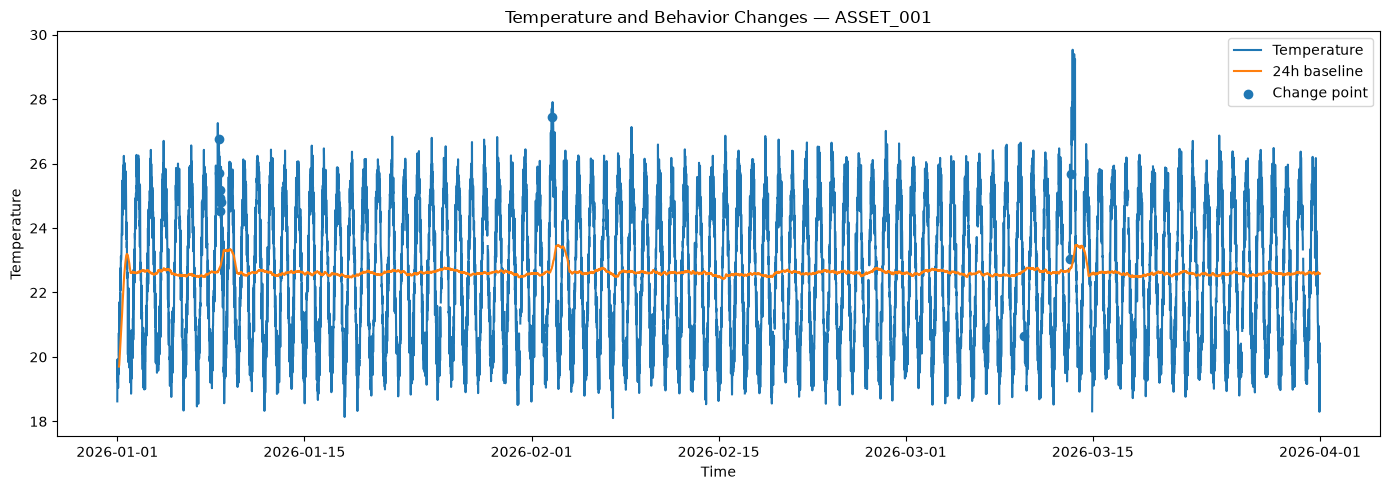

In [14]:
temperature_asset = (
    df.groupby("asset_id")["temperature_stat_anomaly"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

temperature_plot = df[
    df["asset_id"] == temperature_asset
].sort_values("timestamp")

plt.figure(figsize=(14, 5))

plt.plot(
    temperature_plot["timestamp"],
    temperature_plot["temperature"],
    label="Temperature"
)

plt.plot(
    temperature_plot["timestamp"],
    temperature_plot["temperature_mean_24h"],
    label="24h baseline"
)

change_points = temperature_plot[
    temperature_plot["change_point_signal"] == 1
]

plt.scatter(
    change_points["timestamp"],
    change_points["temperature"],
    label="Change point"
)

plt.title(
    f"Temperature and Behavior Changes — {temperature_asset}"
)
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.tight_layout()
plt.show()

### 10.4 Combined Anomaly Score

**Purpose:** show periods where multiple detectors agree that equipment behavior is unusual.

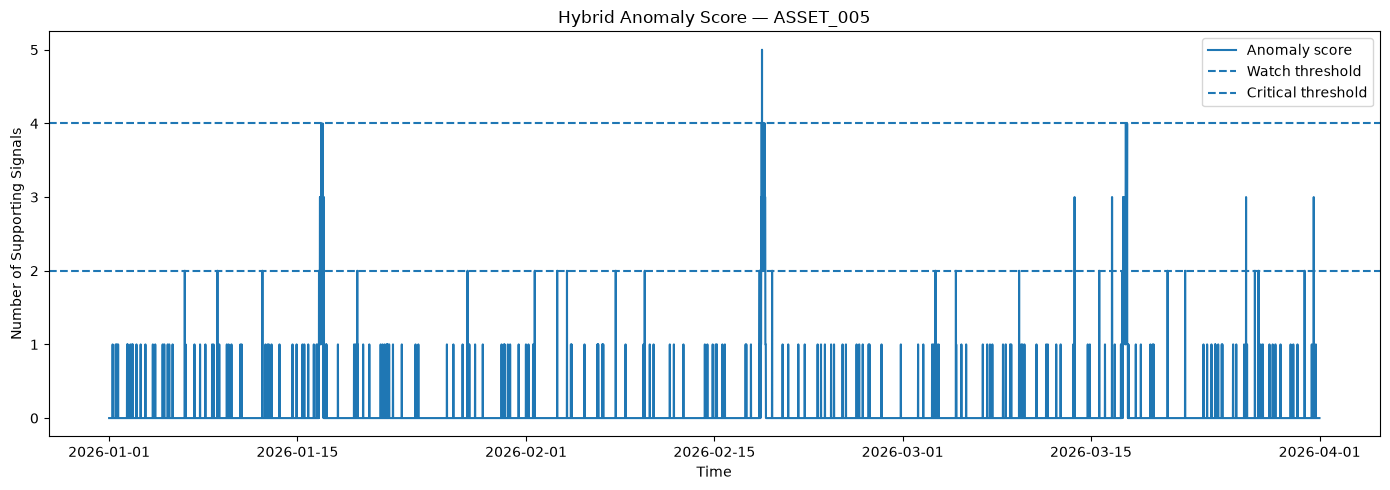

In [15]:
# Asset with the highest maximum anomaly score
score_asset = (
    df.groupby("asset_id")["anomaly_score"]
    .max()
    .sort_values(ascending=False)
    .index[0]
)

score_plot = df[
    df["asset_id"] == score_asset
].sort_values("timestamp")

plt.figure(figsize=(14, 5))

plt.plot(
    score_plot["timestamp"],
    score_plot["anomaly_score"],
    label="Anomaly score"
)

plt.axhline(
    2,
    linestyle="--",
    label="Watch threshold"
)

plt.axhline(
    4,
    linestyle="--",
    label="Critical threshold"
)

plt.title(f"Hybrid Anomaly Score — {score_asset}")
plt.xlabel("Time")
plt.ylabel("Number of Supporting Signals")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Anomaly Summary

Individual telemetry rows may produce repeated alerts for the same underlying event.

Therefore, create both:
- a detailed anomaly table
- an asset-level operational summary

This makes the output more useful for maintenance teams.

In [16]:
def primary_reason(row):

    if row["vibration_stat_anomaly"] == 1:
        return "Excessive vibration"

    if row["power_consumption_stat_anomaly"] == 1:
        return "Sudden power deviation"

    if row["temperature_stat_anomaly"] == 1:
        return "Abnormal temperature"

    if row["pressure_stat_anomaly"] == 1:
        return "Abnormal pressure"

    if row["change_point_signal"] == 1:
        return "Behavior change / possible degradation"

    if row["autoencoder_anomaly"] == 1:
        return "Multivariate abnormal behavior"

    if row["isolation_forest_anomaly"] == 1:
        return "Multivariate outlier"

    if row["cluster_anomaly"] == 1:
        return "Cluster outlier"

    return "Normal"

df["primary_reason"] = df.apply(
    primary_reason,
    axis=1
)

anomalies = df[
    df["anomaly_score"] >= 2
].copy()

anomaly_columns = [
    "timestamp",
    "site_id",
    "building_id",
    "asset_id",
    "asset_type",
    "temperature",
    "vibration",
    "pressure",
    "power_consumption",
    "statistical_anomaly",
    "isolation_forest_anomaly",
    "autoencoder_anomaly",
    "cluster_anomaly",
    "change_point_signal",
    "anomaly_score",
    "severity",
    "primary_reason"
]

print("Detailed anomaly records:", len(anomalies))

display(
    anomalies[
        anomaly_columns
    ]
    .sort_values(
        ["anomaly_score", "timestamp"],
        ascending=[False, False]
    )
    .head(30)
)

Detailed anomaly records: 2046


,timestamp,site_id,building_id,asset_id,asset_type,temperature,vibration,pressure,power_consumption,statistical_anomaly,isolation_forest_anomaly,autoencoder_anomaly,cluster_anomaly,change_point_signal,anomaly_score,severity,primary_reason
203735,2026-02-22 05:45:00,SITE_03,BLDG_05,ASSET_024,Pump,23.057,0.483,4.252,6.313,1,1,1,1,1,5,Critical,Excessive vibration
39220,2026-02-18 13:00:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,24.158,0.335,0.992,117.323,1,1,1,1,1,5,Critical,Excessive vibration
172553,2026-03-29 10:15:00,SITE_02,BLDG_04,ASSET_020,Energy Meter,26.141,0.356,1.021,83.291,1,1,1,1,0,4,Critical,Excessive vibration
172549,2026-03-29 09:15:00,SITE_02,BLDG_04,ASSET_020,Energy Meter,24.953,1.532,1.099,79.663,1,1,1,1,0,4,Critical,Excessive vibration
51381,2026-03-27 05:15:00,SITE_01,BLDG_02,ASSET_006,Chiller,27.304,0.819,1.519,11.483,1,1,1,1,0,4,Critical,Excessive vibration
51380,2026-03-27 05:00:00,SITE_01,BLDG_02,ASSET_006,Chiller,24.987,0.592,1.633,6.146,1,1,1,1,0,4,Critical,Excessive vibration
51374,2026-03-27 03:30:00,SITE_01,BLDG_02,ASSET_006,Chiller,24.144,0.616,1.831,11.701,1,1,1,1,0,4,Critical,Excessive vibration
51363,2026-03-27 00:45:00,SITE_01,BLDG_02,ASSET_006,Chiller,22.210,0.471,1.549,7.793,1,0,1,1,1,4,Critical,Excessive vibration
85774,2026-03-25 11:30:00,SITE_01,BLDG_02,ASSET_010,Energy Meter,24.830,0.044,1.236,282.339,1,1,1,1,0,4,Critical,Sudden power deviation
33931,2026-03-25 10:45:00,SITE_01,BLDG_01,ASSET_004,Pump,25.208,0.656,4.589,16.506,1,1,1,1,0,4,Critical,Excessive vibration


In [17]:
# Asset-level operational summary

asset_summary = (
    df.groupby(
        ["site_id", "building_id", "asset_id", "asset_type"]
    )
    .agg(
        anomaly_count=(
            "anomaly_score",
            lambda x: (x >= 2).sum()
        ),
        critical_count=(
            "severity",
            lambda x: (x == "Critical").sum()
        ),
        max_anomaly_score=("anomaly_score", "max"),
        avg_power=("power_consumption", "mean"),
        avg_vibration=("vibration", "mean"),
        max_vibration=("vibration", "max"),
        avg_temperature=("temperature", "mean")
    )
    .reset_index()
    .sort_values(
        ["critical_count", "anomaly_count"],
        ascending=False
    )
)

display(asset_summary.head(20))

,site_id,building_id,asset_id,asset_type,anomaly_count,critical_count,max_anomaly_score,avg_power,avg_vibration,max_vibration,avg_temperature
23,SITE_03,BLDG_05,ASSET_024,Pump,161,15,5,7.677761,0.236566,1.335,23.188589
0,SITE_01,BLDG_01,ASSET_001,Chiller,128,13,4,43.189302,0.183774,0.877,22.627763
18,SITE_02,BLDG_04,ASSET_019,Pump,125,13,4,7.650467,0.275168,1.803,23.651091
13,SITE_02,BLDG_03,ASSET_014,Pump,114,12,4,7.419703,0.259400,1.343,21.114819
4,SITE_01,BLDG_01,ASSET_005,Energy Meter,119,11,5,60.797017,0.083526,0.585,21.360858
8,SITE_01,BLDG_02,ASSET_009,Pump,109,11,4,7.610697,0.256320,1.710,22.958829
10,SITE_02,BLDG_03,ASSET_011,Chiller,121,8,4,41.987623,0.167806,0.848,22.041116
15,SITE_02,BLDG_04,ASSET_016,Chiller,138,5,4,42.023242,0.167529,0.900,22.134460
5,SITE_01,BLDG_02,ASSET_006,Chiller,131,4,4,46.319828,0.179008,1.064,23.874027
19,SITE_02,BLDG_04,ASSET_020,Energy Meter,87,4,4,65.373965,0.082363,1.532,23.174238


In [18]:
# Summary by asset type

asset_type_summary = (
    df.groupby("asset_type")
    .agg(
        anomaly_count=(
            "anomaly_score",
            lambda x: (x >= 2).sum()
        ),
        critical_count=(
            "severity",
            lambda x: (x == "Critical").sum()
        ),
        average_anomaly_score=("anomaly_score", "mean")
    )
    .sort_values(
        "anomaly_count",
        ascending=False
    )
)

display(asset_type_summary)

,anomaly_count,critical_count,average_anomaly_score
asset_type,,,
Chiller,618,33,0.080556
Pump,615,55,0.055864
Energy Meter,444,22,0.055285
AHU,369,7,0.031800


## 12. Business Recommendations

Translate anomaly signals into operational actions.

### Sudden power spikes
- Investigate unexpected load increases.
- Check HVAC operating mode and occupancy context.
- Compare against the building's normal energy pattern.

### Excessive vibration
- Prioritize pump/chiller inspection.
- Check rotating/mechanical components.
- Monitor repeated vibration increases for degradation.

### Abnormal temperature
- Check HVAC operation and cooling/heating performance.
- Validate the sensor against related measurements.
- Investigate persistent deviations rather than isolated values alone.

### Sensor drift / behavior change
- Compare short-term and long-term baselines.
- Cross-check with related sensors.
- Consider calibration or sensor replacement if the deviation persists.

### Equipment degradation
- Track repeated anomalies at the asset level.
- Combine anomaly alerts with the predictive-maintenance model from Task 2.
- Prioritize assets showing persistent power/vibration deterioration.

> **Important:** An anomaly is not automatically a failure. It indicates behavior that differs from the learned or historical pattern and should trigger investigation.

## Final Deliverables

This notebook provides:

- **Anomaly detection methodology**
- **Five anomaly-detection techniques**
- **Power, vibration, temperature and hybrid-score visualizations**
- **Detailed anomaly records**
- **Asset-level anomaly summary**
- **Business recommendations**

### Interview summary

> "I used a hybrid anomaly-detection framework because different abnormal behaviors have different signatures. Statistical thresholds provide interpretable sensor-level alerts, Isolation Forest and an autoencoder capture multivariate abnormal behavior, DBSCAN identifies isolated operating patterns, and change-point analysis detects persistent shifts such as drift or degradation. I then combine these signals into an evidence-based anomaly score and aggregate repeated alerts at the asset level for operational decisions." 

In [19]:
# 13. Save Anomaly Detection Artifacts for the Dashboard

import joblib
import json

MODEL_DIR = OUTPUTS_DIR / "models" / "anomaly_detection"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save trained unsupervised models and their preprocessing objects.
joblib.dump(
    {
        "isolation_forest": isolation_forest,
        "if_imputer": if_imputer,
        "if_scaler": if_scaler,
        "if_features": if_features,
        "autoencoder": autoencoder,
        "ae_imputer": ae_imputer,
        "ae_scaler": ae_scaler,
        "ae_features": ae_features,
        "ae_threshold": float(ae_threshold),
        "cluster_imputer": cluster_imputer,
        "cluster_scaler": cluster_scaler,
        "cluster_features": cluster_features
    },
    MODEL_DIR / "anomaly_detection_models.joblib"
)

anomaly_config = {
    "statistical_method": "asset-level IQR",
    "isolation_forest_contamination": 0.01,
    "autoencoder_threshold_quantile": 0.99,
    "change_signal_threshold": 3,
    "severity_rule": {
        "Critical": "score >= 4",
        "Anomaly": "score == 3",
        "Watch": "score == 2",
        "Normal": "score < 2"
    }
}

with open(MODEL_DIR / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(anomaly_config, f, indent=2)

# Save the hybrid anomaly results used by the dashboard.
anomalies[anomaly_columns].to_csv(
    MODEL_DIR / "anomaly_results.csv",
    index=False
)

asset_summary.to_csv(
    MODEL_DIR / "asset_anomaly_summary.csv",
    index=False
)

asset_type_summary.to_csv(
    MODEL_DIR / "asset_type_anomaly_summary.csv"
)

print("Saved anomaly-detection artifacts to:", MODEL_DIR.resolve())

Saved anomaly-detection artifacts to: C:\Users\priya\OneDrive\Documents\sem 10 INTERN\Challenge\Nectar Task\outputs\models\anomaly_detection
